# Time series tutorial

In [1]:
import numpy as np
import pandas as pd
import datetime as dt

from climada.hazard import Hazard, Centroids
from climada.test import get_test_file

from climada.hazard.timeseries import HazardTimeSeries

In [2]:
# load example hazard object
haz_tc_fl = Hazard.from_hdf5(
    get_test_file("HAZ_DEMO_FL_15")
)  # Historic tropical cyclones in Florida from 1990 to 2004
haz_tc_fl.check()  # Use always the check() method to see if the hazard has been loaded correctly

2025-09-12 16:03:41,210 - climada.hazard.io - INFO - Reading /Users/vgebhart/climada/data/hazard/template/HAZ_DEMO_FL_15/v1/HAZ_DEMO_FL_15.h5


In [3]:
timesteps_months = pd.date_range(
    "2025-01-01",
    "2029-12-31",
    freq="MS",
)
print(timesteps_months[:3])
print(len(timesteps_months), "months from 2025-2029")
timesteps_months = [date.toordinal() for date in timesteps_months]

DatetimeIndex(['2025-01-01', '2025-02-01', '2025-03-01'], dtype='datetime64[ns]', freq='MS')
60 months from 2025-2029


In [4]:
# example seasonality: TCs only in summer months (Jun-Oct) in Florda, Apr and Nov transition months
seasonality_per_month = [0, 0, 0, 0, 0.5, 1, 1, 1, 1, 1, 0.5, 0]
seasonality = np.array(seasonality_per_month * 5)

In [5]:
# sample a number of timeseries
n_timeseries = 50
haz_timeseries = HazardTimeSeries.sample_from_hazard_set(
    haz_tc_fl, n_timeseries, timesteps_months, seasonality=seasonality, seed=None
)
haz_timeseries.check_time_series()

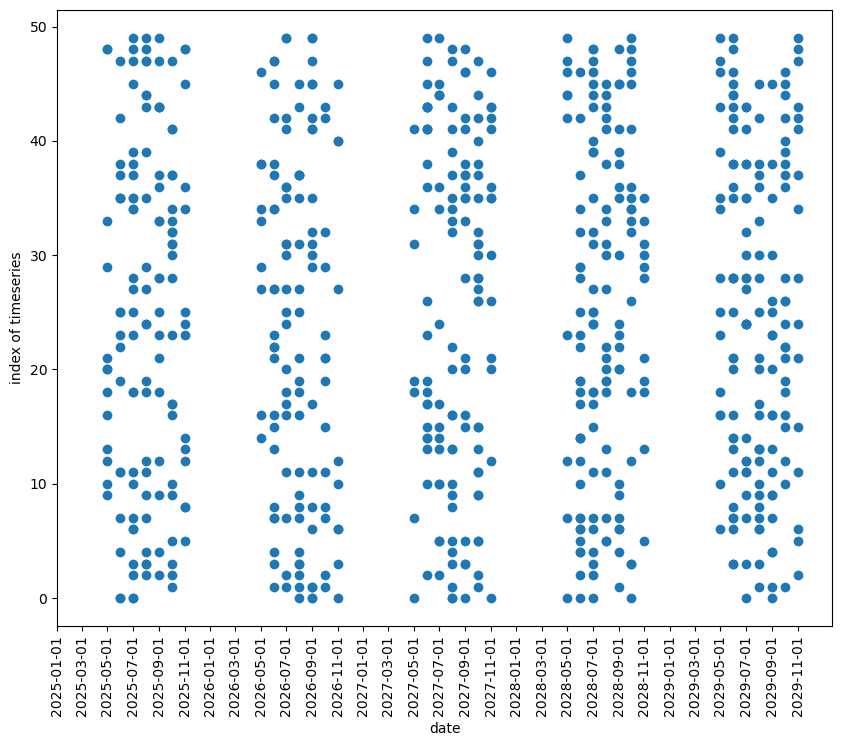

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
plt.xticks(rotation=90)
ax.scatter(haz_timeseries.date, haz_timeseries.id_timeseries)
ax.set_ylabel("index of timeseries")
ax.set_xlabel("date")

ticks = pd.date_range(
    "2025-01-01",
    "2029-12-31",
    freq="2MS",
)
ticks_ord = [date.toordinal() for date in ticks]
ax.set_xticks(ticks_ord)
ax.set_xticklabels(ticks.astype(str));

In [7]:
print(
    np.round(sum(haz_timeseries.frequency), 2),
    "frequency of all events in timeseries object",
)
print(
    np.round(sum(haz_tc_fl.frequency), 2), "frequency of probabilitc event set object"
)

13.74 frequency of all events in timeseries object
14.4 frequency of probabilitc event set object
